In [1]:
import pandas as pd
import pickle
import scipy.stats as stats
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score

In [2]:
info_dict = {
    "session_id": "ID визита",
    "client_id": "ID посетителя",
    "visit_date": "дата визита",
    "visit_time": "время визита",
    "visit_number": "порядковый номер визита клиента",
    "utm_source": "канал привлечения",
    "utm_medium": "тип привлечения",
    "utm_campaign": "рекламная кампания",
    "utm_keyword": "ключевое слово",
    "utm_adcontent": "контент",
    "device_category": "тип устройства",
    "device_os": "ОС устройства",
    "device_brand": "марка устройства",
    "device_model": "модель устройства",
    "device_screen_resolution": "разрешение экрана",
    "device_browser": "браузер",
    "geo_country": "страна",
    "geo_city": "город",
    "hit_date": "дата события",
    "hit_time": "время события",
    "hit_number": "порядковый номер события в рамках сессии",
    "hit_type": "тип события",
    "hit_referer": "источник события",
    "hit_page_path": "страница события",
    "event_category": "тип действия",
    "event_action": "действие",
    "event_label": "тег действия",
    "event_value": "значение результата действия"
}

In [3]:
df1 = pd.read_csv("data\ga_sessions.csv", parse_dates=["visit_date"], low_memory=False)
print("Размерность датасета ga_sessions: ", df1.shape) 
df1.head()

Размерность датасета ga_sessions:  (1860042, 18)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [4]:
df2 = pd.read_csv("data\ga_hits.csv", parse_dates=["hit_date"])
print("Размерность датасета ga_hits: ", df2.shape)  
df2.head()

Размерность датасета ga_hits:  (15726470, 11)


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [5]:
source_df = df1.set_index("session_id").join(df2.set_index("session_id"), how="inner").reset_index()
print("Размерность исходного датасета: ", source_df.shape) 
source_df.head()

Размерность исходного датасета:  (15685219, 28)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,1000009318903347362.1632663668.1632663668,232832813.1632663714,2021-09-26,16:00:00,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,PkybGvWbaqORmxjNunqZ,NaN,...,2021-09-26,NaN,15,event,HbolMJUevblAbkHClEQa,podpiska.sberauto.com/faq?utm_source_initial=y...,sub_page_view,sub_faq,KclpemfoHstknWHFiLit,NaN
1,1000009318903347362.1632663668.1632663668,232832813.1632663714,2021-09-26,16:00:00,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,PkybGvWbaqORmxjNunqZ,NaN,...,2021-09-26,NaN,3,event,HbolMJUevblAbkHClEQa,podpiska.sberauto.com/,sub_page_view,sub_landing,KclpemfoHstknWHFiLit,NaN
2,1000009318903347362.1632663668.1632663668,232832813.1632663714,2021-09-26,16:00:00,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,PkybGvWbaqORmxjNunqZ,NaN,...,2021-09-26,NaN,4,event,HbolMJUevblAbkHClEQa,podpiska.sberauto.com/,listing_ads,go_to_car_card,hAHqGICPFQiPwtzubOzs,NaN
3,1000009318903347362.1632663668.1632663668,232832813.1632663714,2021-09-26,16:00:00,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,PkybGvWbaqORmxjNunqZ,NaN,...,2021-09-26,NaN,9,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/2fc745ed?utm_source_initial=...,card_web,view_card,KclpemfoHstknWHFiLit,NaN
4,1000009318903347362.1632663668.1632663668,232832813.1632663714,2021-09-26,16:00:00,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,PkybGvWbaqORmxjNunqZ,NaN,...,2021-09-26,NaN,8,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/2fc745ed?utm_source_initial=...,card_web,view_new_card,KclpemfoHstknWHFiLit,NaN


In [6]:
del df1, df2

In [7]:
# Пропуски и дублирование строк
full_na = source_df.isnull().all(axis=1).sum()
print("Полностью пустых строк: ", full_na)
print("Дублирующихся строк:", source_df.duplicated().sum())

Полностью пустых строк:  0
Дублирующихся строк: 0


In [8]:
df = source_df.copy()

In [9]:
# Формирование целевого признака
cols = ['sub_car_claim_click', 'sub_car_claim_submit_click',
'sub_open_dialog_click', 'sub_custom_question_submit_click',
'sub_call_number_click', 'sub_callback_submit_click', 'sub_submit_success',
'sub_car_request_submit_click']

df["event_value"] = df["event_action"].isin(cols)

In [10]:
df.tail()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
15685214,999988617151873171.1623556243.1623556243,232827993.1623556243,2021-06-13,06:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,NaN,...,2021-06-13,NaN,2,event,HbolMJUevblAbkHClEQa,podpiska.sberauto.com/,sub_page_view,sub_landing,KclpemfoHstknWHFiLit,False
15685215,999988617151873171.1623556243.1623556243,232827993.1623556243,2021-06-13,06:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,NaN,...,2021-06-13,NaN,4,event,HbolMJUevblAbkHClEQa,podpiska.sberauto.com/,sub_button_click,sub_view_cars_click,vodKSlUobUWTVlgsJqdI,False
15685216,999988617151873171.1623556243.1623556243,232827993.1623556243,2021-06-13,06:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,NaN,...,2021-06-13,NaN,7,event,HbolMJUevblAbkHClEQa,sberauto.com/cars?city=1&rental_page=rental_on...,search_form,search_form_region,vjCtPQgqItKOqWsBPymc,False
15685217,999988617151873171.1623556243.1623556243,232827993.1623556243,2021-06-13,06:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,NaN,...,2021-06-13,NaN,8,event,HbolMJUevblAbkHClEQa,sberauto.com/cars?city=1&rental_page=rental_on...,search_form,search_form_search_btn,ghOrjqpgskpGHSFfBBsi,False
15685218,999989480451054428.1634311006.1634311006,232828194.1634311004,2021-10-15,18:00:00,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,NaN,...,2021-10-15,NaN,3,event,HbolMJUevblAbkHClEQa,podpiska.sberauto.com/,sub_page_view,sub_landing,KclpemfoHstknWHFiLit,False


# Описание признаков

In [11]:
# Датафрейм с информацией о переменных
def descr_features(data):
    features = data.dtypes.to_frame(name="data_type")# Тип даных в столбце
    features["meaning"] = [info_dict.get(x, "new") for x in features.index] # Текстовое описание
    features["n_NaN"] = data.isna().sum() # Количество пропущенных значений
    features["%NaN"] = round(features["n_NaN"] / len(data) * 100, 2) # Процент пропущенных значений
    features["nunique"] = data.nunique().values # Количество уникальных значений
    describe_df = data.describe(include="all", datetime_is_numeric=True).round(1).T.drop(columns=['unique']) 
    features = pd.merge(features, describe_df.round(0),  how="left", left_index=True, right_index=True) # Информация describe()
    return features

In [12]:
descr_features(df)

,data_type,meaning,n_NaN,%NaN,nunique,count,top,freq,mean,min,25%,50%,75%,max,std
session_id,object,ID визита,0,0.00,1732266,15685219,5442565791571325612.1632449195.1632449195,768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_id,object,ID посетителя,0,0.00,1320704,15685219,1750498477.1629450062,6871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_date,datetime64[ns],дата визита,0,0.00,226,15685219,NaN,NaN,2021-09-22 19:43:56.383081984,2021-05-19 00:00:00,2021-07-25 00:00:00,2021-10-02 00:00:00,2021-11-22 00:00:00,2021-12-31 00:00:00,NaN
visit_time,object,время визита,0,0.00,85032,15685219,13:00:00,544567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_number,int64,порядковый номер визита клиента,0,0.00,533,15685219.0,NaN,NaN,2.7,1.0,1.0,1.0,2.0,564.0,12.5
utm_source,object,канал привлечения,700,0.00,280,15684519,ZpYIoDJMcFzVoPFsHGJL,5151702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_medium,object,тип привлечения,0,0.00,55,15685219,banner,4898563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_campaign,object,рекламная кампания,2198873,14.02,406,13486346,LTuZkdKfxRGVceoWkVyg,5166521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_adcontent,object,контент,2832418,18.06,280,12852801,JNHcPlZPxEMWDnRiyoBf,9647665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_keyword,object,ключевое слово,9204827,58.68,1192,6480392,puhZPIYqKXeFPaUviSjo,4717082,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Сбалансированность выборки

In [13]:
df["event_value"].value_counts()

False    15582377
True       102842
Name: event_value, dtype: int64

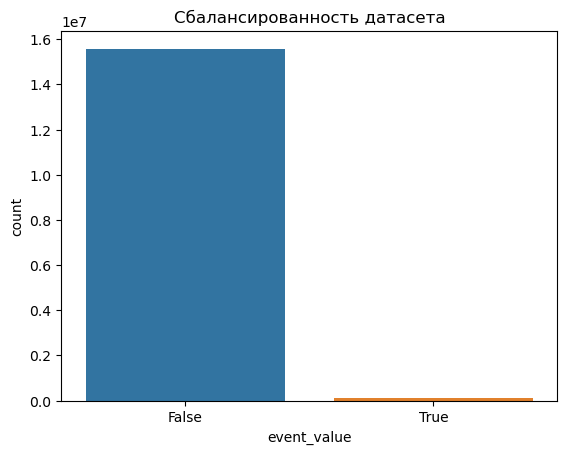

In [14]:
sns.countplot(x="event_value", data=df);
plt.title("Сбалансированность датасета");

In [15]:
drop_num = source_df.shape[0] - 230000

# Удаляем случайные строки 
random_rows = df[df.event_value == False].sample(n=drop_num, random_state=42)
df = df.drop(random_rows.index)
del random_rows

Соотношение классов: 55.29% на 44.71%


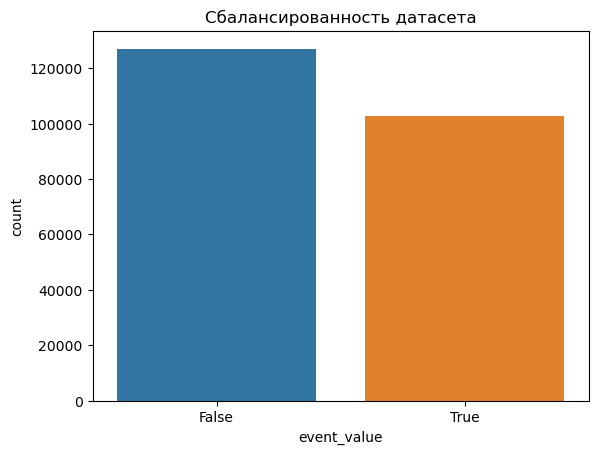

In [16]:
sns.countplot(x="event_value", data=df);
plt.title("Сбалансированность датасета");
perc_true = round(df[df.event_value==True].shape[0] / df.shape[0] * 100, 2)
print(f"Соотношение классов: {100 - perc_true}% на {perc_true}%")

# Data Preparation

## Удаление неинформативных признаков

In [17]:
print("Формат значений времени имеет вид: ", df.hit_time.values)
print("Количество уникальных значений hit_type: ", df.hit_type.nunique())
print("На основании признака event_action создан целевой")
print("Столбцы visit_date и hit_date идентичны", (df.visit_date == df.hit_date).value_counts().index)

Формат значений времени имеет вид:  [nan nan nan ... nan nan nan]
Количество уникальных значений hit_type:  1
На основании признака event_action создан целевой
Столбцы visit_date и hit_date идентичны Index([True], dtype='object')


In [18]:
for col in ["utm_keyword", "hit_referer", "device_model"]:
    val_sum = df.loc[:, col].isna().sum()  + df.loc[:, col].describe().freq
    print(f"Доля значений NaN и моды в признаке {col} равна {val_sum/df.shape[0]}")

Доля значений NaN и моды в признаке utm_keyword равна 0.8904826086956522
Доля значений NaN и моды в признаке hit_referer равна 0.9501260869565218
Доля значений NaN и моды в признаке device_model равна 0.9972434782608696


In [19]:
# Удаление столбцов
cols = ["hit_time", "hit_date", "hit_type", "hit_referer", "utm_keyword", "event_action" ]
df.drop(columns=cols, inplace=True)

## Преобразование типов

In [20]:
# Преобразование типов
df["visit_time"] = df["visit_time"].apply(lambda x: datetime.strptime(x, "%H:%M:%S"))

df["utm_source"] = df["utm_source"].astype("str")
df["utm_campaign"] = df["utm_campaign"].astype("str")
df["utm_adcontent"] = df["utm_adcontent"].astype("str")

## Обработка пропущенных значений device_

In [21]:
print("Описание признаков device_")
descr_features(df.loc[:, "device_category":"device_browser"])

Описание признаков device_


,data_type,meaning,n_NaN,%NaN,nunique,count,top,freq
device_category,object,тип устройства,0,0.00,3,230000,mobile,170809
device_os,object,ОС устройства,141632,61.58,9,88368,Android,47782
device_brand,object,марка устройства,57263,24.90,88,172737,Apple,66967
device_model,object,модель устройства,228292,99.26,63,1708,AuMdmADEIoPXiWpTsBEj,1074
device_screen_resolution,object,разрешение экрана,0,0.00,1113,230000,414x896,20501
device_browser,object,браузер,0,0.00,21,230000,Chrome,123428


### device_brand

In [22]:
# Для всех моделей AuMdm бренд не задан
df.device_brand[df.device_model=="AuMdmADEIoPXiWpTsBEj"].unique() 

array(['(not set)'], dtype=object)

In [23]:
# Если бренд не задан, то модель устройства не задана или AuMdmADEIoPXiWpTsBEj 
df_new = df.device_model[df["device_brand"]=="(not set)"] 
print("Значения моделей для (no set) бренда : ", df_new.unique())
print("Где доля 'AuMdmADEIoPXiWpTsBEj': ",df_new.notna().sum() / df_new.shape[0])
del df_new

Значения моделей для (no set) бренда :  ['AuMdmADEIoPXiWpTsBEj' nan]
Где доля 'AuMdmADEIoPXiWpTsBEj':  0.5496417604912999


In [24]:
# Если в бренде пропущенно значение, то оно пропущено и в модели
df.device_model[df.device_brand.isna()].unique()

array([nan], dtype=object)

In [25]:
# Заполняем пропуски в бренде (доля 25%) на (no set)
df.device_brand = df.device_brand.fillna("(not set)")

# Заполняем (not set) бренда моделью AuMdmADEIoPXiWpTsBE (доля >50%)
condition = (df["device_brand"] == "(not set)") & (df["device_model"] == "AuMdmADEIoPXiWpTsBEj")
df.loc[condition, "device_brand"] = "AuMdm"

In [26]:
# Сокращаем количество значений бренда
df["device_brand"] = df["device_brand"].replace(["Realme", "OnePlus", "OPPO", "Vivo"], "BBK Electronics")

In [27]:
# Популярные бренды
top_values = df['device_brand'].value_counts().nlargest(7).index
print(top_values)

# Заменяем остальные значения на "other"
df.loc[~df['device_brand'].isin(top_values), 'device_brand'] = 'other'

Index(['Apple', '(not set)', 'Samsung', 'Xiaomi', 'Huawei', 'BBK Electronics',
       'AuMdm'],
      dtype='object')


In [28]:
# Удаляем признак device_model
print("Количество пропусков в модели девайса ", df.device_model.isna().sum())
df.drop(columns="device_model", inplace=True)

Количество пропусков в модели девайса  228292


###  device_os 

In [29]:
# Операционные системы категории desktop
df.device_os[df.device_category == "desktop"].unique()

array([nan, 'Macintosh', 'Windows', 'Linux', 'Chrome OS', '(not set)',
       'iOS'], dtype=object)

In [30]:
# Заменяем непопулярные ОС на other
values = ["Tizen", "Chrome OS", "BlackBerry", "Firefox OS", "Nokia", "Windows Phone", "Samsung", "Linux", "(not set)"]
df["device_os"] = df["device_os"].replace(values, "other")
df.device_os.unique()

array([nan, 'Android', 'iOS', 'Macintosh', 'Windows', 'other'],
      dtype=object)

In [31]:
# Заполнение пропусков ОС в Apple, Google и Nokia
mask = df["device_brand"] == "Apple"
df.loc[mask, "device_os"] = df.loc[mask, "device_os"].fillna("iOS")

mask = (df["device_brand"] == "Google") | (df["device_brand"] == "Nokia")
df.loc[mask, "device_os"] = df.loc[mask, "device_os"].fillna("other")

# Заполнение пропусков ОС для ПК
mask = df["device_category"] == "desktop"
df.loc[mask, "device_os"] = df.loc[mask, "device_os"].fillna("Windows")

df.device_os = df.device_os.fillna("Android")

### device_browser

In [32]:
df.device_browser.unique()

array(['Chrome', 'Safari', 'Android Webview', 'YaBrowser',
       'Safari (in-app)', 'Samsung Internet', 'Edge', 'Opera', 'Firefox',
       'UC Browser', 'Mozilla Compatible Agent', 'com.vk.vkclient',
       'Android Runtime', 'MRCHROME', 'Maxthon', 'Mozilla', 'Opera Mini',
       'Puffin', '[FBAN', 'Instagram 208.0.0.32.135 Android',
       'Instagram 209.0.0.21.119 Android'], dtype=object)

In [33]:
# Сократим кол-во значений, взяв первое слово
df.device_browser = df.device_browser.apply(lambda x: x.split()[0])
df.device_browser.unique()

array(['Chrome', 'Safari', 'Android', 'YaBrowser', 'Samsung', 'Edge',
       'Opera', 'Firefox', 'UC', 'Mozilla', 'com.vk.vkclient', 'MRCHROME',
       'Maxthon', 'Puffin', '[FBAN', 'Instagram'], dtype=object)

In [34]:
# Популярные браузеры
top_values = df['device_browser'].value_counts().nlargest(5).index
print(top_values)

# Заменяем остальные значения на "other"
df.loc[~df['device_browser'].isin(top_values), 'device_browser'] = 'other'

Index(['Chrome', 'Safari', 'YaBrowser', 'Android', 'Samsung'], dtype='object')


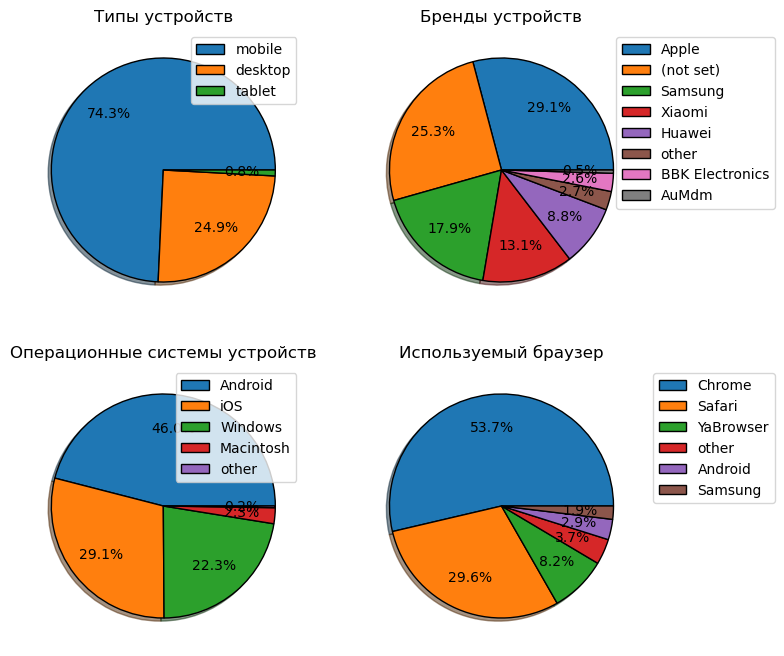

In [35]:
plt.figure(figsize=(8,8));

params = {
    "shadow": True, 
    "wedgeprops": {'lw':1, 'ls':'-','edgecolor':'k'}, 
    "autopct": "%1.1f%%", 
    "pctdistance" : 0.7, 
    "labeldistance": None}

# Диаграмма для столбца 'device_category'
plt.subplot(2, 2, 1)
plt.pie(df.device_category.value_counts(),labels=df.device_category.unique(), **params)
plt.title("Типы устройств");
plt.legend();

# Диаграмма для столбца 'device_brand'
plt.subplot(2, 2, 2)
plt.pie(df.device_brand.value_counts(), labels=df.device_brand.value_counts().index, **params)
plt.title("Бренды устройств");
plt.legend(bbox_to_anchor=(1, 0, 0.5, 1));

# Диаграмма для столбца 'device_os'
plt.subplot(2, 2, 3)
plt.pie(df.device_os.value_counts(), labels=df.device_os.value_counts().index, **params)
plt.title("Операционные системы устройств");
plt.legend();

# Диаграмма для столбца 'device_browser'
plt.subplot(2, 2, 4)
plt.pie(df.device_browser.value_counts(), labels=df.device_browser.value_counts().index, **params)
plt.title("Используемый браузер");
plt.legend(bbox_to_anchor=(1, 0, 0.5, 1));

In [36]:
print("Описание признаков device_")
descr_features(df.loc[:, "device_category":"device_browser"])

Описание признаков device_


,data_type,meaning,n_NaN,%NaN,nunique,count,top,freq
device_category,object,тип устройства,0,0.0,3,230000,mobile,170809
device_os,object,ОС устройства,0,0.0,5,230000,Android,105788
device_brand,object,марка устройства,0,0.0,8,230000,Apple,66967
device_screen_resolution,object,разрешение экрана,0,0.0,1113,230000,414x896,20501
device_browser,object,браузер,0,0.0,6,230000,Chrome,123428


## Обработка значений utm_

In [37]:
print("Описание признаков utm")
descr_features(df.loc[:, "utm_source":"utm_campaign"])

Описание признаков utm


,data_type,meaning,n_NaN,%NaN,nunique,count,top,freq
utm_source,object,канал привлечения,0,0.0,148,230000,ZpYIoDJMcFzVoPFsHGJL,73921
utm_medium,object,тип привлечения,0,0.0,36,230000,banner,69986
utm_campaign,object,рекламная кампания,0,0.0,298,230000,LTuZkdKfxRGVceoWkVyg,79547


### utm_medium

In [38]:
# Отнесём (not set) к группе media (как и самое частое banner)
df.utm_medium.value_counts()[:10]

banner             69986
cpc                47894
(none)             46603
referral           32838
cpm                10889
organic             9228
push                3871
email               2879
blogger_channel     1136
stories              916
Name: utm_medium, dtype: int64

In [39]:
# Формирование групп привлечения

df["utm_medium"] = df["utm_medium"].replace(["cpc", "google_cpc", "yandex_cpc", "cpm", "CPM", 
                                               "cpv", "last", "users_msk", "reach", "cpa", "clicks", "linktest"], "efficiency")
df["utm_medium"] = df["utm_medium"].replace(["banner", "static", "cbaafe", "dom_click", "nkp","link","smartbanner", 
                                               "qrcodevideo", "medium", "tablet", "(not set)","partner", "sber_app",
                                               "qr","promo_sber","promo_sbol", "Sbol_catalog", "catalogue", "app"], "media")
df["utm_medium"] = df["utm_medium"].replace([ "smm", "stories", "blogger_channel", "blogger_stories", "vk_smm",
                                               "fb_smm", "ok_smm", "social", "tg", "blogger_header", "post", "article"], "blog")
df["utm_medium"] = df["utm_medium"].replace([ "organic", "(none)", "referral", "landing", "landing_interests",
                                                "web_polka", "main_polka"], "seo")
df["utm_medium"] = df["utm_medium"].replace(["email", "info_text", "outlook", "sms", "push"], "info")

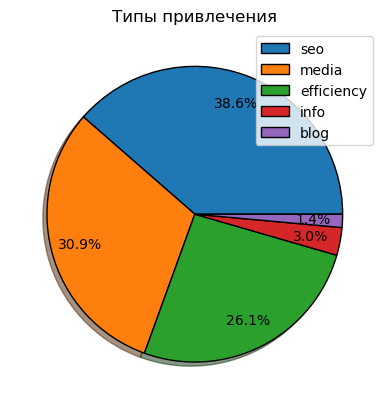

In [40]:
# Диаграмма для столбца 'utm_medium'

plt.pie(df.utm_medium.value_counts(), labels=df.utm_medium.value_counts().index, 
        shadow=True, wedgeprops={'lw':1, 'ls':'-','edgecolor':'k'}, 
        autopct="%1.1f%%", pctdistance=0.8, labeldistance=None)
plt.title("Типы привлечения");
plt.legend();

## Удаление значений event_

In [41]:
# Удаляем признаки, так как они содержат информацию о целевом
df.drop(columns=["event_category", "event_label"], inplace=True)

## Обработка значений geo_

In [42]:
print("Описание признаков geo")
descr_features(df.loc[:, "geo_country":"geo_city"])

Описание признаков geo


,data_type,meaning,n_NaN,%NaN,nunique,count,top,freq
geo_country,object,страна,0,0.0,104,230000,Russia,224673
geo_city,object,город,0,0.0,985,230000,Moscow,106226


### geo_city

In [43]:
# Популярные города
top_values = df['geo_city'].value_counts().nlargest(10).index.tolist()
top_values.remove("(not set)")
print(top_values)

# Заменяем остальные значения на "other"
df.loc[~df['geo_city'].isin(top_values), 'geo_city'] = 'other'

['Moscow', 'Saint Petersburg', 'Kazan', 'Krasnodar', 'Yekaterinburg', 'Samara', 'Ufa', 'Nizhny Novgorod', 'Novosibirsk']


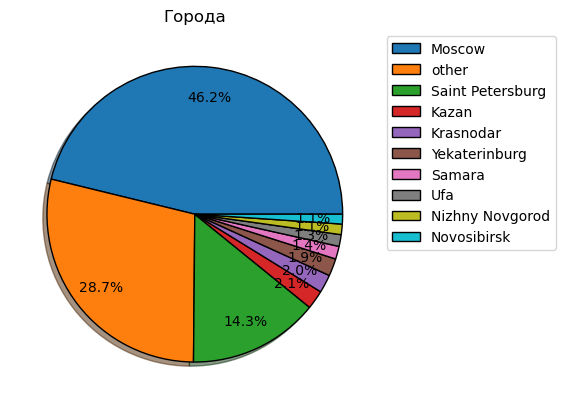

In [44]:
# Диаграмма для столбца 'geo_city'
plt.pie(df.geo_city.value_counts(), labels=df.geo_city.value_counts().index, 
        shadow=True, wedgeprops={'lw':1, 'ls':'-','edgecolor':'k'}, 
        autopct="%1.1f%%", pctdistance=0.8, labeldistance=None)
plt.title("Города");
plt.legend(bbox_to_anchor=(1, 0, 0, 1));

## Построение новых признаков 

In [45]:
df["device_pixels"] = df['device_screen_resolution'].apply(lambda x: int(x.split('x')[0]) * int(x.split('x')[1]))

In [46]:
df["visit_freq"] = df['visit_number'].apply(lambda x: 'low' if x < 3 else ('high' if x > 50 else 'medium'))

In [47]:
df["visit_month"] = df["visit_date"].apply(lambda x: x.month)
df["visit_day"] = df["visit_date"].apply(lambda x: x.day)
df["visit_hour"] = df["visit_time"].apply(lambda x: x.hour)

In [48]:
df["geo_russian"] = df['geo_country'].apply(lambda x: True if x == "Russia" else False )

In [49]:
df["utm_source0"] = df["utm_source"].apply(lambda x: x[0])
df["utm_adcontent0"] = df["utm_adcontent"].apply(lambda x: x[0])
df["utm_campaign0"] = df["utm_campaign"].apply(lambda x: x[0])

In [50]:
# Сокращение кол-ва значений новых признаков utm_

top_values = df['utm_adcontent0'].value_counts().nlargest(5).index
df.loc[~df['utm_adcontent0'].isin(top_values), 'utm_adcontent0'] = 'other'

top_values = df['utm_source0'].value_counts().nlargest(7).index
df.loc[~df['utm_source0'].isin(top_values), 'utm_source0'] = 'other'

top_values = df['utm_campaign0'].value_counts().nlargest(5).index
df.loc[~df['utm_campaign0'].isin(top_values), 'utm_campaign0'] = 'other'

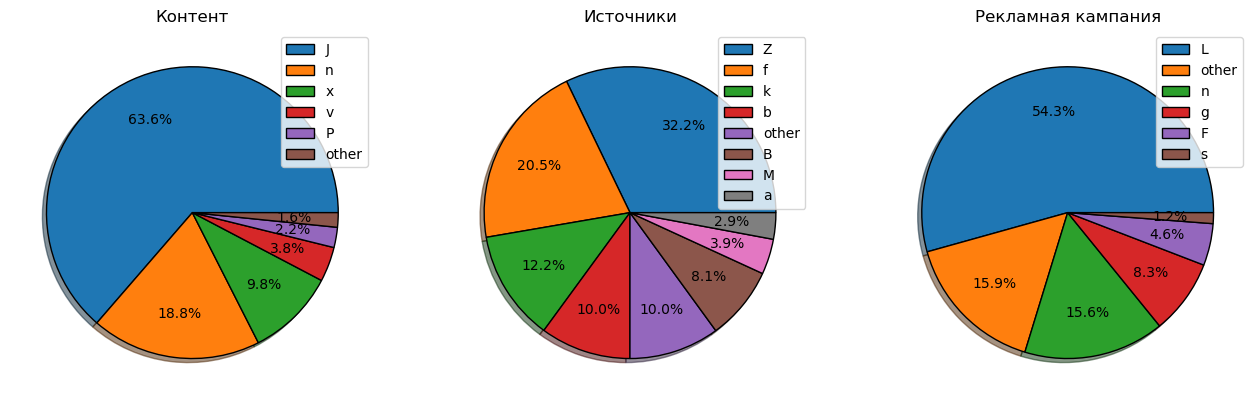

In [51]:
# Диаграммы новых признаков utm_
plt.figure(figsize=(16,16));

params = {
    "shadow": True, 
    "wedgeprops": {'lw':1, 'ls':'-','edgecolor':'k'}, 
    "autopct": "%1.1f%%", 
    "pctdistance" : 0.7, 
    "labeldistance": None}

# Диаграмма для столбца 'utm_adcontent0'
plt.subplot(1, 3, 1)
plt.pie(df.utm_adcontent0.value_counts(),labels=df.utm_adcontent0.unique(), **params)
plt.title("Контент");
plt.legend();

# Диаграмма для столбца 'utm_source0'
plt.subplot(1, 3, 2)
plt.pie(df.utm_source0.value_counts(), labels=df.utm_source0.value_counts().index, **params)
plt.title("Источники");
plt.legend();

# Диаграмма для столбца 'utm_campaign0'
plt.subplot(1, 3, 3)
plt.pie(df.utm_campaign0.value_counts(), labels=df.utm_campaign0.value_counts().index, **params)
plt.title("Рекламная кампания");
plt.legend();

In [52]:
print("Корреляция с целевым признаком")
df.corr()["event_value"].round(3)

Корреляция с целевым признаком


visit_number     0.101
hit_number       0.125
event_value      1.000
device_pixels   -0.019
visit_month     -0.087
visit_day       -0.017
visit_hour      -0.014
geo_russian      0.025
Name: event_value, dtype: float64

In [53]:
cols = ["session_id", "client_id", "device_screen_resolution", "hit_page_path",
        "utm_source", "utm_adcontent", "utm_campaign", "visit_date", "visit_time", "geo_country", "hit_number"]
df.drop(columns=cols, inplace=True)

## Обработка выбросов

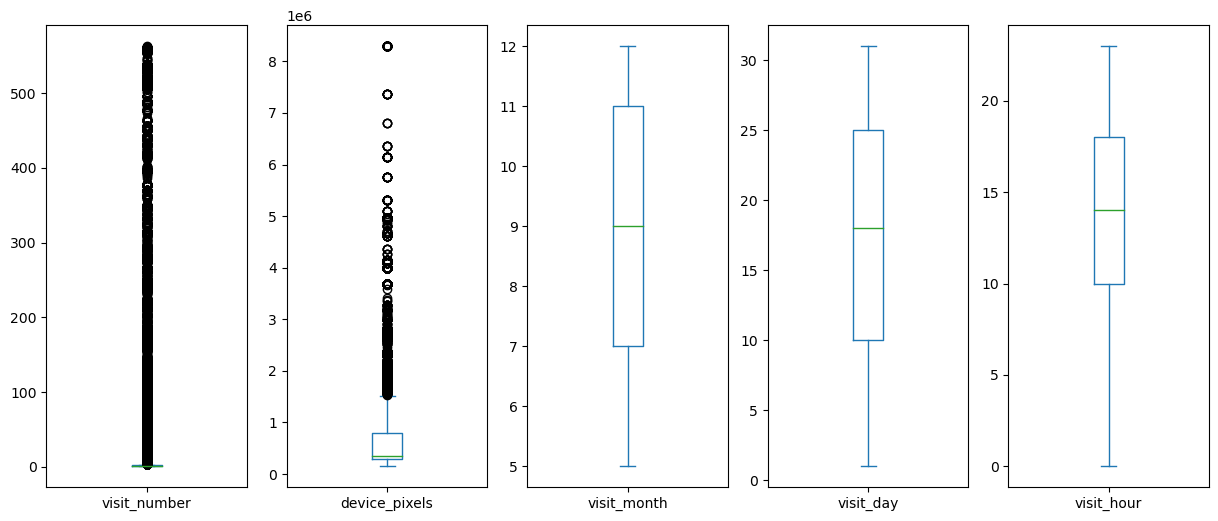

In [54]:
df.plot(kind="box", sharex=False, subplots=True, figsize=(15,6));

In [55]:
def get_bounds(column):
    q25 = df[column].quantile(0.25) # Рассчёт интерквартильного размаха
    q75 = df[column].quantile(0.75)
    iqr = q75 - q25
    bound = (q25 - iqr * 1.5, q75 + iqr * 1.5)
    out_of_bound = ( df[column] > bound[1]) | ( df[column] < bound[0])
    anom_count = df[column][ out_of_bound ].count()
    
    print("\033[1m",column,"\033[0m")
    print("Интерквартильный размах", bound)
    print(f"Диапазон значений: ({df[column].min()}; {df[column].max()})")
    print("Количество выбросов: ", anom_count)
    print("Их процент в выборке: ", anom_count / len(df) * 100, '\n')
    
    return [bound[0], bound[1], out_of_bound]

In [56]:
bounds = get_bounds("device_pixels")
condition = df.device_pixels < 240*320

df.loc[condition, "device_pixels"] = 240*320 # Замена логически малых значений
df.loc[bounds[2], "device_pixels"] = bounds[1] # Замена выбросов верхней границей

 device_pixels 
Интерквартильный размах (-459648.0, 1534080.0)
Диапазон значений: (153600; 8294400)
Количество выбросов:  29033
Их процент в выборке:  12.62304347826087 



In [57]:
#  Замена выбросов верхней границей
bounds = get_bounds("visit_number")
df.loc[bounds[2], "visit_number"] = bounds[1]

 visit_number 
Интерквартильный размах (-0.5, 3.5)
Диапазон значений: (1; 563)
Количество выбросов:  29389
Их процент в выборке:  12.777826086956523 



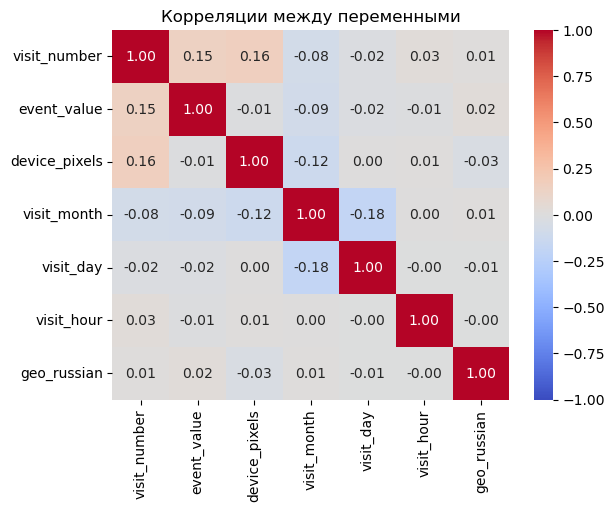

In [58]:
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap="coolwarm", vmin=-1, vmax=1, center=0);
plt.title("Корреляции между переменными");

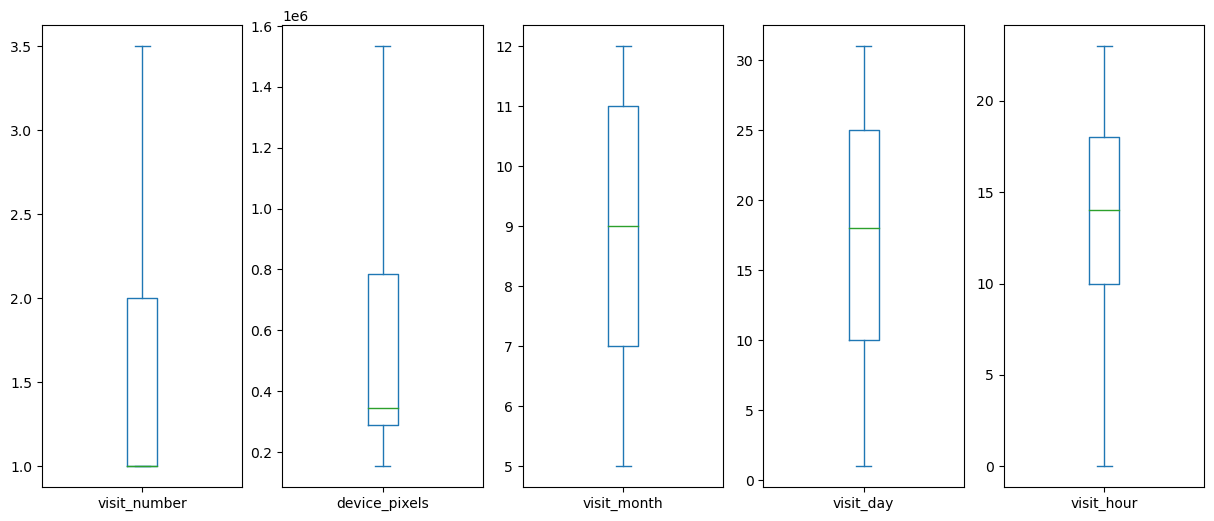

In [59]:
df.plot(kind="box", sharex=False, subplots=True, figsize=(15,6));

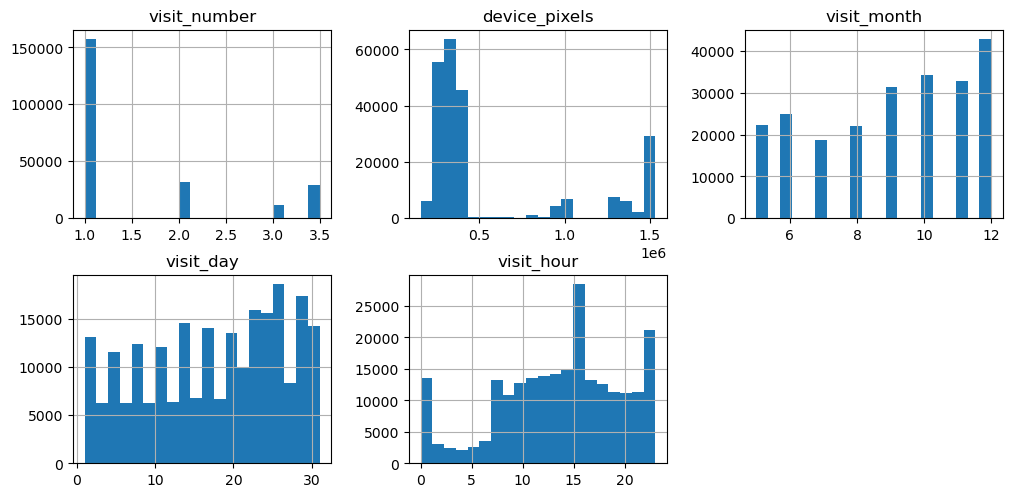

In [60]:
df.hist(figsize=(12,12), layout=(4,3), bins=20, sharex=False);

In [61]:
descr_features(df)

,data_type,meaning,n_NaN,%NaN,nunique,count,top,freq,mean,std,min,25%,50%,75%,max
visit_number,float64,порядковый номер визита клиента,0,0.0,4,230000.0,NaN,NaN,1.6,0.9,1.0,1.0,1.0,2.0,3.5
utm_medium,object,тип привлечения,0,0.0,5,230000,seo,88726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_category,object,тип устройства,0,0.0,3,230000,mobile,170809,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_os,object,ОС устройства,0,0.0,5,230000,Android,105788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_brand,object,марка устройства,0,0.0,8,230000,Apple,66967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_browser,object,браузер,0,0.0,6,230000,Chrome,123428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_city,object,город,0,0.0,10,230000,Moscow,106226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_value,bool,значение результата действия,0,0.0,2,230000,False,127158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_pixels,int64,new,0,0.0,847,230000.0,NaN,NaN,577816.0,465798.8,153600.0,288000.0,343089.0,786432.0,1534080.0
visit_freq,object,new,0,0.0,3,230000,low,189136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
del source_df

## Data visualisation

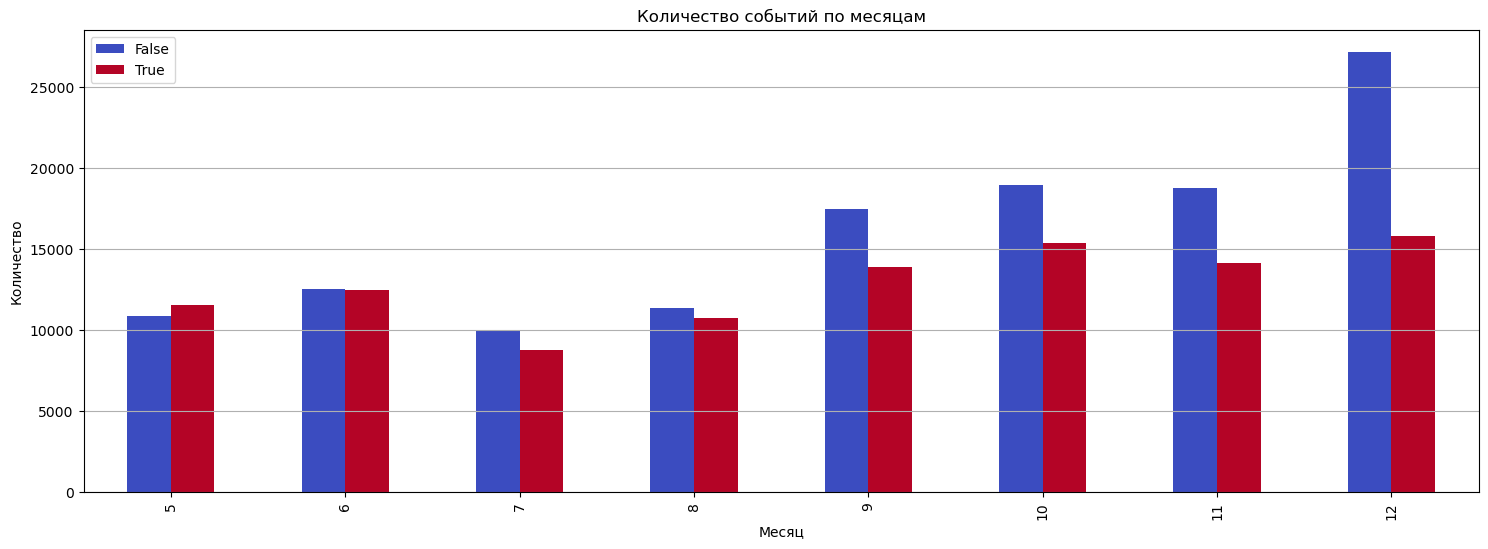

In [63]:
grouped = df.groupby(['visit_month', 'event_value'])["event_value"].count().unstack()

# Построение графика
grouped.plot(kind='bar', figsize=(18, 6), cmap="coolwarm")

plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.title('Количество событий по месяцам')
plt.legend()
plt.grid(axis='y')

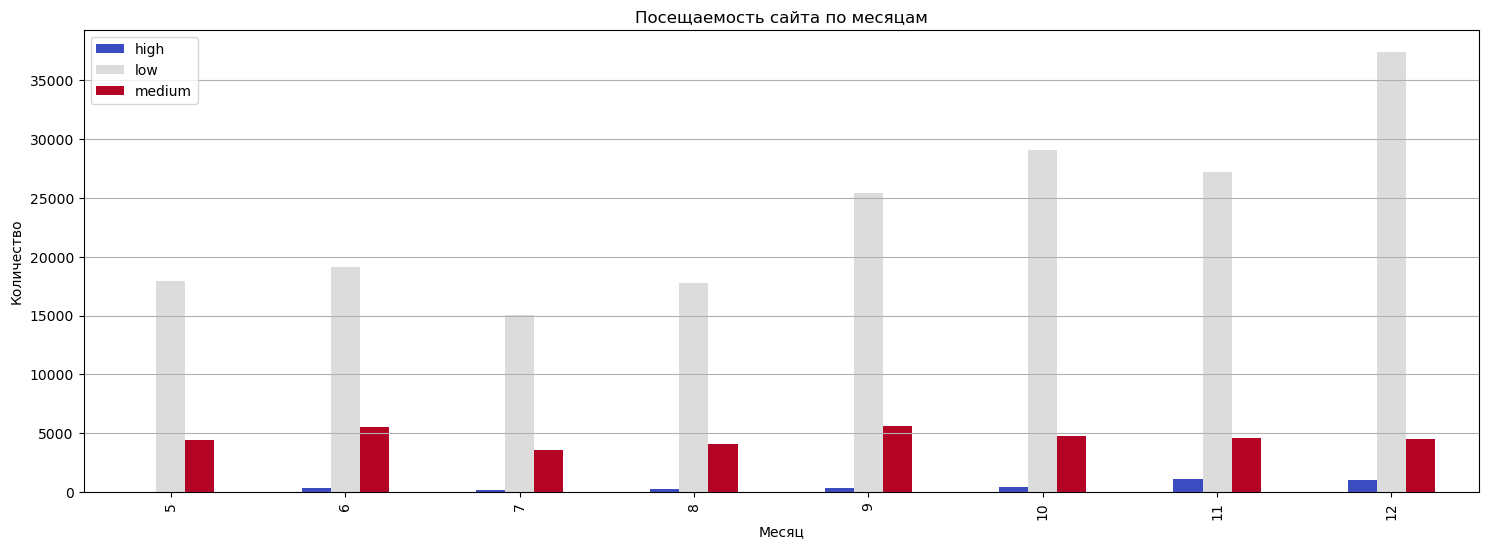

In [64]:
grouped = df.groupby(['visit_month', 'visit_freq'])["visit_freq"].count().unstack()

# Построение графика
grouped.plot(kind='bar', figsize=(18, 6), cmap="coolwarm")

plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.title('Посещаемость сайта по месяцам')
plt.legend()
plt.grid(axis='y')

In [65]:
df.visit_month.value_counts()

12    43001
10    34320
11    32913
9     31410
6     25033
5     22391
8     22116
7     18816
Name: visit_month, dtype: int64

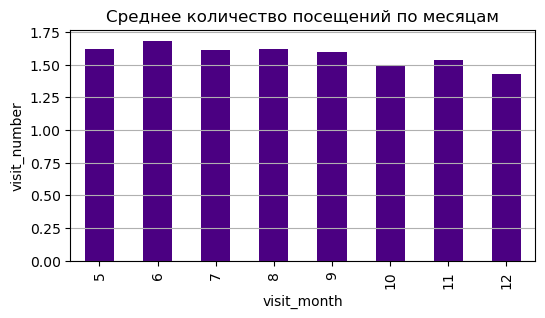

In [66]:
grouped = df.groupby('visit_month')['visit_number'].mean()

# Построение графика
plt.figure(figsize=(6, 3))
grouped.plot(kind='bar', color='indigo')
plt.title('Среднее количество посещений по месяцам')
plt.xlabel('visit_month')
plt.ylabel('visit_number')
plt.grid(axis='y')

# Показать график
plt.show()

# Нормализация данных

In [67]:
df.to_csv("data\clean_data.csv")

In [68]:
df_prep = df.copy()

In [69]:
print("Корреляция с целевым признаком")
df_prep.corr()["event_value"].sort_values()

Корреляция с целевым признаком


visit_month     -0.086700
visit_day       -0.016788
visit_hour      -0.014099
device_pixels   -0.011934
geo_russian      0.024877
visit_number     0.147777
event_value      1.000000
Name: event_value, dtype: float64

In [70]:
# StandardScaler
num_vars = df_prep.select_dtypes(include=['number']).columns.tolist()
data = df_prep[num_vars]

std_scaler = StandardScaler()
std_scaler.fit(data)
matrix = std_scaler.transform(data) # Результат стандартизации 
names = [x + "_std" for x in num_vars] # Названия столбцов
df_prep[names] = matrix 
del std_scaler

df_prep[names].head() 

,visit_number_std,device_pixels_std,visit_month_std,visit_day_std,visit_hour_std
37,-0.61204,-0.637650,-1.304163,-0.593397,-0.279360
184,-0.61204,-0.503925,-0.008894,-0.366603,0.890630
233,-0.61204,-0.444124,-1.304163,0.540570,1.057772
245,-0.61204,-0.534623,1.286375,0.200380,-0.780785
249,-0.61204,-0.534623,1.286375,0.200380,-0.780785


In [71]:
# Преобразование bool признаков в int
bool_vars = df_prep.select_dtypes(include=['bool']).columns.tolist()
for col in bool_vars:
    df_prep[col] = df_prep[col].astype(int)

In [72]:
 # Датафрейм с категориальными переменными
cat_vars = df_prep.select_dtypes(include=['object']).columns.tolist()
data = df_prep[cat_vars]

# OneHotEncoder
ohe = OneHotEncoder(sparse=False)
matrix = ohe.fit_transform(data) # Преобразованные значения
names = ohe.get_feature_names_out() # Названия новых колонок
df_prep[names] = matrix
df_prep[names].head()

del data, names, ohe, matrix

In [73]:
df_prep.drop(columns=cat_vars, inplace=True)
df_prep.drop(columns=num_vars, inplace=True)

In [74]:
print("Размер df_prep: ", df_prep.shape)

Размер df_prep:  (230000, 67)


In [75]:
df_prep.corr()

,event_value,geo_russian,visit_number_std,device_pixels_std,visit_month_std,visit_day_std,visit_hour_std,utm_medium_blog,utm_medium_efficiency,utm_medium_info,...,utm_adcontent0_n,utm_adcontent0_other,utm_adcontent0_v,utm_adcontent0_x,utm_campaign0_F,utm_campaign0_L,utm_campaign0_g,utm_campaign0_n,utm_campaign0_other,utm_campaign0_s
event_value,1.000000,0.024877,0.147777,-0.011934,-0.086700,-0.016788,-0.014099,-0.034265,-0.007472,-0.017201,...,0.007454,-0.058581,-0.067102,-0.005468,-0.007484,0.014478,0.038126,0.033166,-0.078138,0.003802
geo_russian,0.024877,1.000000,0.013305,-0.032931,0.013213,-0.006661,-0.002717,-0.033744,0.020074,-0.001204,...,0.010444,0.013824,0.004136,0.008080,0.019295,-0.026155,0.018955,0.016210,-0.006415,0.001896
visit_number_std,0.147777,0.013305,1.000000,0.163818,-0.079984,-0.021333,0.029020,-0.027343,0.132290,-0.041899,...,0.225702,-0.017019,-0.126215,-0.053695,-0.093956,-0.039194,-0.101983,0.274744,-0.075049,-0.043736
device_pixels_std,-0.011934,-0.032931,0.163818,1.000000,-0.123447,0.004782,0.010663,-0.015007,0.067370,-0.002553,...,0.106604,0.139459,-0.185683,0.021384,0.018326,0.015934,-0.165538,0.121168,-0.009311,-0.061279
visit_month_std,-0.086700,0.013213,-0.079984,-0.123447,1.000000,-0.184779,0.002093,-0.026332,0.131721,0.131923,...,0.064494,0.090696,0.388768,0.129885,0.079161,-0.244548,0.087202,0.079659,0.100870,0.140152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
utm_campaign0_L,0.014478,-0.026155,-0.039194,0.015934,-0.244548,0.044759,0.010567,-0.131943,-0.626522,-0.189875,...,-0.505767,-0.212902,0.300347,-0.165140,-0.240767,1.000000,-0.328042,-0.468743,-0.474862,-0.120429
utm_campaign0_g,0.038126,0.018955,-0.101983,-0.165538,0.087202,-0.077855,-0.010632,0.011750,-0.178190,-0.053238,...,-0.144710,-0.060167,-0.099296,-0.045534,-0.066387,-0.328042,1.000000,-0.129246,-0.130933,-0.033206
utm_campaign0_n,0.033166,0.016210,0.274744,0.121168,0.079659,-0.059383,-0.004257,0.019695,0.629178,-0.076002,...,0.799718,-0.083544,-0.141643,-0.065064,-0.094861,-0.468743,-0.129246,1.000000,-0.187092,-0.047448
utm_campaign0_other,-0.078138,-0.006415,-0.075049,-0.009311,0.100870,0.015021,0.002014,0.170539,0.179784,0.213079,...,0.080795,0.334774,-0.140784,-0.062863,-0.096099,-0.474862,-0.130933,-0.187092,1.000000,-0.048067


# Modeling

In [76]:
x = df_prep.drop(['event_value'], axis=1)
y = df_prep['event_value']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [77]:
df_prep.to_csv("data\prep_data.csv")

## Обучение модели случайного леса

In [78]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

# Оценка точности предсказания
print('Accuracy на тренировочной выборке:', rf.score(x_train, y_train))
print('Accuracy: на тестовой выборке:', accuracy_score(y_test, rf_pred))
print("F-мера: ", f1_score(y_test, rf_pred))

Accuracy на тренировочной выборке: 0.9559316770186336
Accuracy: на тестовой выборке: 0.7571449275362319
F-мера:  0.7287677441284538


In [79]:
rf_base = RandomForestClassifier() # базовая модель

# Сетка параметров
param_grid = {
    'max_depth': [10, 15],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [1,0]
}

clf = GridSearchCV(
   estimator=rf_base,
   param_grid=param_grid,
   scoring='roc_auc',
   verbose=2
)
# Поиск наилучших параметров с помощью случайного поиска
best_rf = clf.fit(x_train, y_train)
best_rf.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .......bootstrap=1, max_depth=10, max_features=sqrt; total time=  14.7s
[CV] END .......bootstrap=1, max_depth=10, max_features=sqrt; total time=  14.3s
[CV] END .......bootstrap=1, max_depth=10, max_features=sqrt; total time=  14.3s
[CV] END .......bootstrap=1, max_depth=10, max_features=sqrt; total time=  14.2s
[CV] END .......bootstrap=1, max_depth=10, max_features=sqrt; total time=  13.9s
[CV] END .......bootstrap=1, max_depth=10, max_features=log2; total time=  11.1s
[CV] END .......bootstrap=1, max_depth=10, max_features=log2; total time=  13.2s
[CV] END .......bootstrap=1, max_depth=10, max_features=log2; total time=  12.3s
[CV] END .......bootstrap=1, max_depth=10, max_features=log2; total time=  11.6s
[CV] END .......bootstrap=1, max_depth=10, max_features=log2; total time=  11.1s
[CV] END .......bootstrap=1, max_depth=15, max_features=sqrt; total time=  22.2s
[CV] END .......bootstrap=1, max_depth=15, max_fe

RandomForestClassifier(bootstrap=0, max_depth=15, max_features='sqrt')

In [80]:
# Обучение модели с лучшими из найденных параметров
rf = best_rf.best_estimator_
rf_pred = rf.predict(x_test)

# Оценка точности предсказания
print('Accuracy на тренировочной выборке:', rf.score(x_train, y_train))
print('Accuracy: на тестовой выборке:', accuracy_score(y_test, rf_pred))
print("F-мера: ", f1_score(y_test, rf_pred))

Accuracy на тренировочной выборке: 0.7161739130434782
Accuracy: на тестовой выборке: 0.6645072463768116
F-мера:  0.5530649676609712


In [81]:
# Поиск наименее важных фичей для дерева решений
f_imp_list = dict(zip(x_train.columns, rf.feature_importances_))
f_imp_list

{'geo_russian': 0.004422882589480846,
 'visit_number_std': 0.07079312596102386,
 'device_pixels_std': 0.08596235330499183,
 'visit_month_std': 0.09051661646858634,
 'visit_day_std': 0.09638267402946375,
 'visit_hour_std': 0.09851211374065603,
 'utm_medium_blog': 0.005969629148557601,
 'utm_medium_efficiency': 0.012601196172559942,
 'utm_medium_info': 0.004636319946739284,
 'utm_medium_media': 0.007952950646954777,
 'utm_medium_seo': 0.01101432572055161,
 'device_category_desktop': 0.006788962193167925,
 'device_category_mobile': 0.007481858906325737,
 'device_category_tablet': 0.0021593346451720514,
 'device_os_Android': 0.009435754598624693,
 'device_os_Macintosh': 0.007280119027311901,
 'device_os_Windows': 0.008019304213655645,
 'device_os_iOS': 0.0050503175552641015,
 'device_os_other': 0.00339113883435819,
 'device_brand_(not set)': 0.006447621013194341,
 'device_brand_Apple': 0.0044671246617574495,
 'device_brand_AuMdm': 0.0012693179949545494,
 'device_brand_BBK Electronics': 0.0

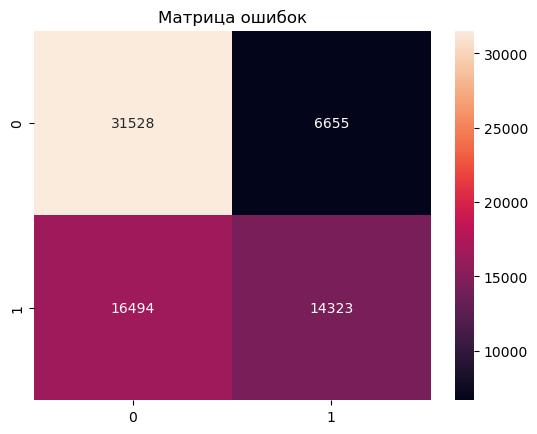

In [82]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='.0f');
plt.title("Матрица ошибок");

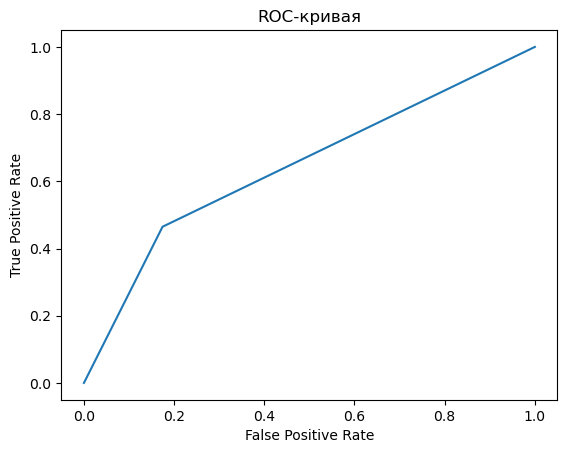

ROC_AUC 0.6452418555360286


In [83]:
fpr, tpr, _ = roc_curve(y_test, rf_pred)

# ROC кривая
plt.plot(fpr, tpr)
plt.title("ROC-кривая")
plt.ylabel('True Positive Rate') # TP / TP + FN == recall
plt.xlabel('False Positive Rate')# FP / TP + FN
# precision TP / TP + FP
plt.show()
print("ROC_AUC", roc_auc_score(y_test, rf_pred))

## Обучение логистической регрессии

In [84]:
logreg_base = LogisticRegression()# базовая модель

# Сетка параметров
param_grid =  {
    'penalty' : ['l2'],
    'solver' : ['sag', 'saga', 'liblinear', 'lbfgs', 'newton-cg'],
    'max_iter': [300],
    'C': [1, 0.1, 10]
}

clf = GridSearchCV(
    estimator=logreg_base, 
    param_grid=param_grid,
    cv=4,
    scoring='roc_auc',  
    verbose=2
)

# Поиск наилучших параметров с помощью поиска по сетке
best_log = clf.fit(x_train, y_train)
best_log.best_estimator_

Fitting 4 folds for each of 15 candidates, totalling 60 fits
[CV] END ..........C=1, max_iter=300, penalty=l2, solver=sag; total time=   9.6s
[CV] END ..........C=1, max_iter=300, penalty=l2, solver=sag; total time=   8.2s
[CV] END ..........C=1, max_iter=300, penalty=l2, solver=sag; total time=   8.5s
[CV] END ..........C=1, max_iter=300, penalty=l2, solver=sag; total time=   7.7s
[CV] END .........C=1, max_iter=300, penalty=l2, solver=saga; total time=  17.4s
[CV] END .........C=1, max_iter=300, penalty=l2, solver=saga; total time=  14.6s
[CV] END .........C=1, max_iter=300, penalty=l2, solver=saga; total time=  15.3s
[CV] END .........C=1, max_iter=300, penalty=l2, solver=saga; total time=  14.3s
[CV] END ....C=1, max_iter=300, penalty=l2, solver=liblinear; total time=   2.3s
[CV] END ....C=1, max_iter=300, penalty=l2, solver=liblinear; total time=   1.8s
[CV] END ....C=1, max_iter=300, penalty=l2, solver=liblinear; total time=   1.9s
[CV] END ....C=1, max_iter=300, penalty=l2, solv

LogisticRegression(C=1, max_iter=300, solver='liblinear')

In [85]:
# Обучение модели с лучшими из найденных параметров
logreg = best_log.best_estimator_
logreg.fit(x_train, y_train)
logreg_pred = logreg.predict(x_test)

# Оценка точности предсказания
print('Accuracy на тренировочной выборке:', logreg.score(x_train, y_train))
print('Accuracy на тестовой выборке:', accuracy_score(y_test, logreg_pred))
print("F-мера: ", f1_score(y_test, logreg_pred))

Accuracy на тренировочной выборке: 0.5999440993788819
Accuracy на тестовой выборке: 0.6013333333333334
F-мера:  0.46677521904318836


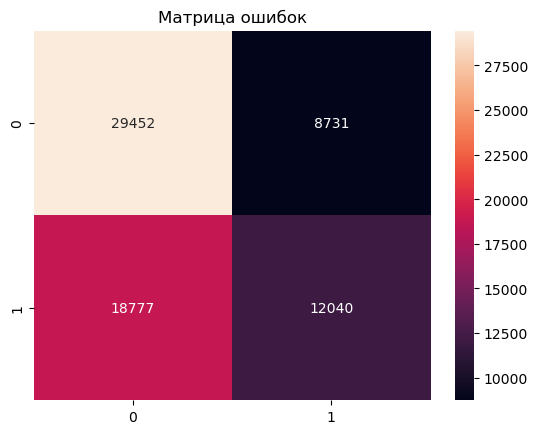

In [86]:
cm = confusion_matrix(y_test, logreg_pred)
sns.heatmap(cm, annot=True, fmt='.0f');
plt.title("Матрица ошибок");

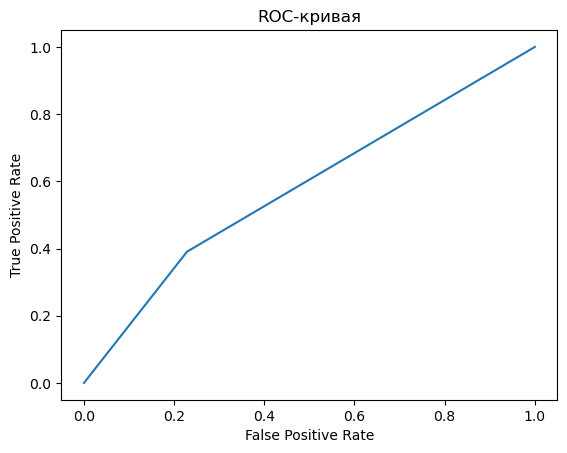

ROC_AUC 0.5810157392173414


In [87]:
fpr, tpr, _ = roc_curve(y_test, logreg_pred)

# ROC кривая
plt.plot(fpr, tpr)
plt.title("ROC-кривая")
plt.ylabel('True Positive Rate') # TP / TP + FN == recall
plt.xlabel('False Positive Rate')# FP / TP + FN
# precision TP / TP + FP
plt.show()
print("ROC_AUC", roc_auc_score(y_test, logreg_pred))

## Обучение многослойного персептрона

In [88]:
mlp_base = MLPClassifier()# базовая модель

# Сетка параметров
param_grid =  {
    'hidden_layer_sizes': [(100,), (50, 20)],
    'activation': ['tanh', 'logistic'],
    'solver': ['lbfgs', 'sgd', 'adam'],
    'alpha': [0.01, 0.001, 0.0001],
    'max_iter': [300, 400]
}

clf = RandomizedSearchCV(
    estimator=mlp_base, 
    param_distributions = param_grid, 
    scoring='roc_auc',  
    verbose=2,
    n_jobs=-1
)

# Поиск наилучших параметров с помощью случайного поиска
best_mlp = clf.fit(x_train, y_train)
best_mlp.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=(50, 20),
              max_iter=400)

In [89]:
#  Обучение модели
mlp = best_mlp.best_estimator_
mlp.fit(x_train, y_train)
mlp_pred = mlp.predict(x_test)

# Оценка точности предсказания
print('Accuracy на тренировочной выборке:', mlp.score(x_train, y_train))
print('Accuracy: на тестовой выборке:', accuracy_score(y_test, mlp_pred))
print('Confusion matrix\n', confusion_matrix(y_test, mlp_pred))

Accuracy на тренировочной выборке: 0.670447204968944
Accuracy: на тестовой выборке: 0.6334492753623189
Confusion matrix
 [[27590 10593]
 [14699 16118]]


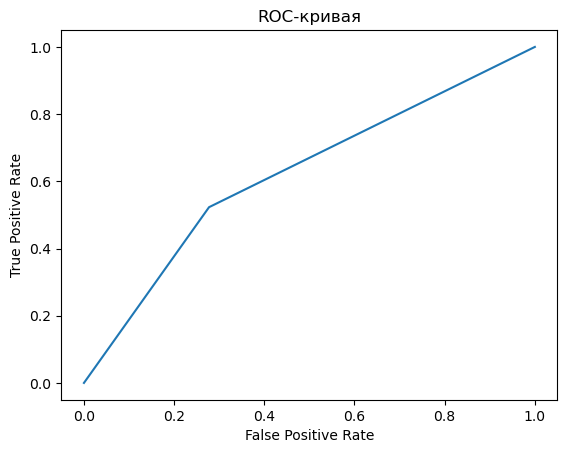

ROC_AUC 0.6227979397631931


In [90]:
fpr, tpr, _ = roc_curve(y_test, mlp_pred)

# ROC кривая
plt.plot(fpr, tpr)
plt.title("ROC-кривая")
plt.ylabel('True Positive Rate') # TP / TP + FN == recall
plt.xlabel('False Positive Rate')# FP / TP + FN
# precision TP / TP + FP
plt.show()
print("ROC_AUC", roc_auc_score(y_test, mlp_pred))

## Выбор лучшей модели

In [91]:
for model in [rf, logreg, mlp]:
    print(f"Результаты кросс-валидации \033[1m {model} \033[0m")
    cv_score = cross_val_score(model, x, y, cv=5)
    print(f"Среднее значение: {cv_score.mean()}, стандартное отклонение: {cv_score.std()}")

Результаты кросс-валидации  RandomForestClassifier(bootstrap=0, max_depth=15, max_features='sqrt') 
Среднее значение: 0.6101347826086957, стандартное отклонение: 0.0067523208920423385
Результаты кросс-валидации  LogisticRegression(C=1, max_iter=300, solver='liblinear') 
Среднее значение: 0.5976695652173913, стандартное отклонение: 0.007409739159008023
Результаты кросс-валидации  MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=(50, 20),
              max_iter=400) 
Среднее значение: 0.5887652173913044, стандартное отклонение: 0.0070718082970193654


**Вывод**: наилучшим образом показала себя модель случайного леса. Она будет финальным результатом данного ноутбука

In [92]:
# Обучение финальной модели
final_model = model 
final_model.fit(x, y)

MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=(50, 20),
              max_iter=400)

In [93]:
# Cохранение в файл
with open("data\model.pickle", 'wb') as file:
    pickle.dump(final_model, file)